In [ ]:
!pip install kaggle

In [ ]:
kaggle = '/content/kaggle.json'

In [ ]:
!mkdir -p ~/.kaggle
!cp {kaggle} ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d olafkrastovski/handwritten-digits-0-9

Dataset URL: https://www.kaggle.com/datasets/olafkrastovski/handwritten-digits-0-9
License(s): CC0-1.0
handwritten-digits-0-9.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
from zipfile import ZipFile
import os
file_name = 'handwritten-digits-0-9.zip'

extract_folder = "dataset"
os.makedirs(extract_folder, exist_ok=True)

with ZipFile(file_name, 'r') as zip:
    zip.extractall(extract_folder)
    print('Done')

Done


In [ ]:
data_0 = os.listdir('/content/dataset/0')
data_1 = os.listdir('/content/dataset/1')
data_2 = os.listdir('/content/dataset/2')
data_3 = os.listdir('/content/dataset/3')
data_4 = os.listdir('/content/dataset/4')
data_5 = os.listdir('/content/dataset/5')
data_6 = os.listdir('/content/dataset/6')
data_7 = os.listdir('/content/dataset/7')
data_8 = os.listdir('/content/dataset/8')
data_9 = os.listdir('/content/dataset/9')

In [ ]:
len(data_0)

2236

# **Load data dan Mengubah Gambar Ke Numerik**

In [ ]:
import os
import cv2
import numpy as pd

X = []
y = []

dataset_path = '/content/dataset'
img_size = 32

In [ ]:
for label in os.listdir(dataset_path):
    label_path = os.path.join(dataset_path, label)

    for file in os.listdir(label_path):
        img_path = os.path.join(label_path, file)

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (img_size, img_size))

        img = img / 255.0    # Normalisasi
        img = img.flatten()  # ANN

        X.append(img)
        y.append(int(label))

In [ ]:
import numpy as np

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(21555, 3072)
(21555,)


# **Split Data Test dan Data Training**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **Modelling – Menentukan Struktur Input untuk Neural Network**

In [ ]:
X_train.shape

(17244, 3072)

In [ ]:
X_train.shape[1]

3072

# **Pembuatan Model Neural Network (Arsitektur ANN)**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.3),

    Dense(10, activation='softmax')
])

# **Kompilasi Model dan Ringkasan Arsitektur (Model Summary)**

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │       196,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 199,082 (777.66 KB)

 Trainable params: 199,082 (777.66 KB)

 Non-trainable params: 0 (0.00 B)

# **Early Stopping (Pencegahan Overfitting Selama Training)**

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# **Training Model Neural Network**

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
863/863 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.1013 - loss: 2.3579 - val_accuracy: 0.1073 - val_loss: 2.3019
Epoch 2/100
863/863 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.1026 - loss: 2.3050 - val_accuracy: 0.1073 - val_loss: 2.3022
Epoch 3/100
863/863 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.1095 - loss: 2.3026 - val_accuracy: 0.0989 - val_loss: 2.3024
Epoch 4/100
863/863 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.1040 - loss: 2.3027 - val_accuracy: 0.1073 - val_loss: 2.3022
Epoch 5/100
863/863 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.1005 - loss: 2.3025 - val_accuracy: 0.1073 - val_loss: 2.3022
Epoch 6/100
863/863 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.1034 - loss: 2.3024 - val_accuracy: 0.0989 - val_loss: 2.3022


# **Evaluasi Model (Testing Data)**

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss     :", loss)
print("Test Accuracy :", accuracy)

135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1064 - loss: 2.3018
Test Loss     : 2.302065849304199
Test Accuracy : 0.10206448286771774


# **Visualisasi Hasil Pelatihan (Accuracy dan Loss)**

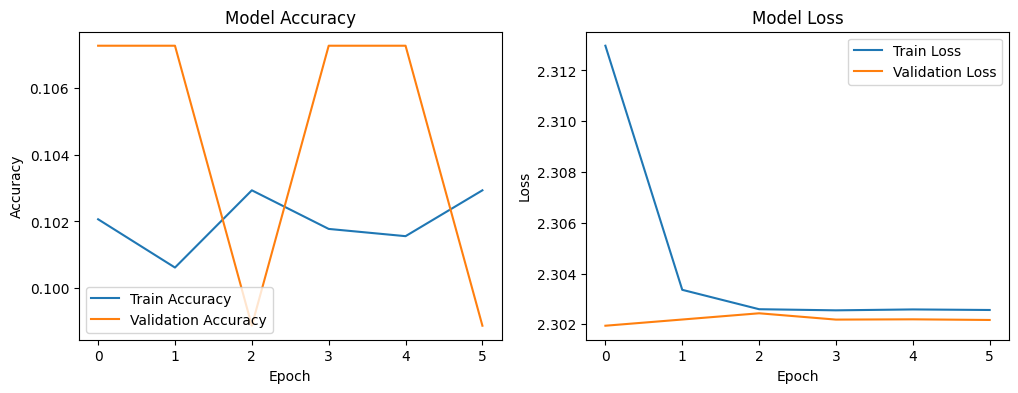

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()